In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# add Code folder
import sys
sys.path.append('../../qdarts')

# import main class and plotting function
from experiment import Experiment
from plotting import plot_polytopes

# import standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec



## Device definition

In [3]:
# Define the system

#All capacitances are given in aF
N = 6 #number of dots   
C_DD =np.diag(np.random.normal(20, 1,size=N))/2 #The self-capacitance of each dot, NOTE: factor of 2 due to symmetrization
C_DD += np.random.normal(5, 1, size=((N,N)))

C_DD = C_DD + C_DD.T

C_DG = np.diag(np.random.normal(10, 1,size=N))/2 
#cross-capacitances
C_DG += np.random.normal(2, 1, size=((N,N)))

# Definition of the tunnel couplings in eV 
# NOTE: we use the convention that tc is the energy gap at avoided crossing H = tc/2 sx
tunnel_couplings = np.zeros((N,N))
for k in range(N-1):
    tc = np.random.normal(50*1e-6, 10*1e-6)
    tunnel_couplings[k,k+1] = tc
    tunnel_couplings[k+1,k] = tc


In [4]:
capacitance_config = {
        "C_DD" : C_DD,  #dot-dot capacitance matrix
        "C_Dg" : C_DG,  #dot-gate capacitance matrix
        "ks" : None,       #distortion of Coulomb peaks. NOTE: If None -> constant size of Coublomb peak 
}

tunneling_config = {
        "tunnel_couplings": tunnel_couplings, #tunnel coupling matrix
        "temperature": 0.1,                   #temperature in Kelvin
        "energy_range_factor": 2,  #energy scale for the Hamiltonian generation. NOTE: Smaller -> faster but less accurate computation 
}
sensor_config = {
        "sensor_dot_indices": [],  #Indices of the sensor dots
        "sensor_detunings": [-0.0005],  #Detuning of the sensor dots
        "noise_amplitude": {"fast_noise": 0.8*1e-4, "slow_noise": 1e-6}, #Noise amplitude for the sensor dots in eV
        "peak_width_multiplier": 15,  #Width of the sensor peaks in the units of thermal broadening m *kB*T/0.61.
}


In [17]:
np.save('C_DD.npy', C_DD)
np.save('C_Dg.npy', C_DG)
np.save('tunnel_couplings.npy', tunnel_couplings)

In [5]:
# Create the experiment object from the configuration files
experiment = Experiment(capacitance_config, tunneling_config, sensor_config)

EXPERIMENT INITIALIZED
-----------------------

                Capacitance model deployed with the following parameters:
                Dot-dot capacitances: 
                [[34.84150582 11.57102462  8.92155597  9.67883547  8.42929045 12.82703896]
 [11.57102462 32.5211766  10.64662808  8.87428694 12.13267645  9.24578581]
 [ 8.92155597 10.64662808 29.05471868 11.66110549 10.94228146  7.98338146]
 [ 9.67883547  8.87428694 11.66110549 31.6377603   9.15290219  9.71226684]
 [ 8.42929045 12.13267645 10.94228146  9.15290219 30.4904797   9.00220486]
 [12.82703896  9.24578581  7.98338146  9.71226684  9.00220486 29.25640774]]
                Dot-gate capacitances: 
                [[ 6.4077817   2.54886652  2.52989522  1.4307247   2.17534093  1.67241247]
 [ 1.64620708  6.93418502  1.07859188 -0.06433466  0.29131663  2.28963873]
 [ 1.78691458  3.02908476  5.90519513  2.69787985  3.40696569  2.38314714]
 [ 1.93593214  3.30098636  3.58216789  7.25121877  2.39837389  2.21280414]
 [ 2.44515642  3

In [14]:
xexp, yexp, csd_data, polytopes_data, sensor_signalexp, _ = experiment.generate_CSD(
                                    plane_axes = np.array([[1,0,0,0,0,0],[0,1,0,0,0,0]]), # vectors spanning the cut in voltage space
                                    target_state = [4,4,1,1,1,0],  # target state for transition
                                    target_transition = [1,-1,0,0,0,0],
                                    x_voltages=np.linspace(-0.012, 0.01, 100), #voltage range for x-axis
                                    y_voltages=np.linspace(-0.012, 0.01, 100), #voltage range for y-axis
                                    compute_polytopes = True, #compute the corners of constant occupation
                                    compensate_sensors=False, #compensate the sensor signals
                                    use_virtual_gates= False, #use the virtual gates
                                    use_sensor_signal=False) #use the sensor signals

v_offset found: [ 0.13052874  0.1131189   0.0179793  -0.00664428 -0.02018101 -0.15243305]


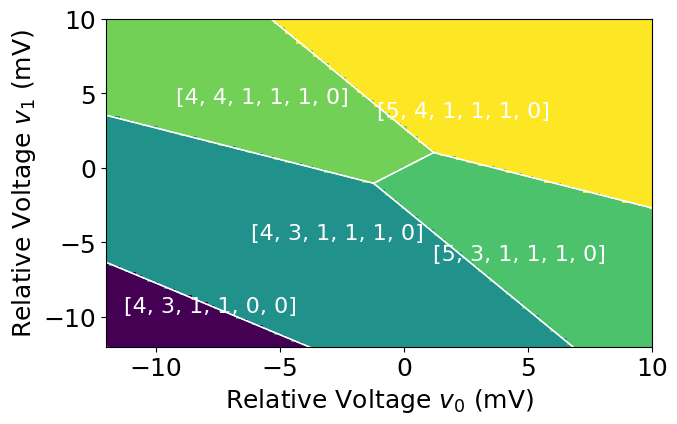

In [18]:
plt.figure(figsize=(6, 4))


# Define the grid
gs = gridspec.GridSpec(1, 1)
plt.subplots_adjust(wspace=0.3, top = 0.98, bottom = 0.16, left = 0.08, right = 0.99)

# Create subplots
ax0 = plt.subplot(gs[0])


#plot the csd with background polytopes
ax0.pcolormesh(1e3*xexp,1e3*yexp,csd_data) #plot the background
plot_polytopes(ax0,polytopes_data, axes_rescale = 1e3, skip_dots = [], fontsize=16) #plot the polytopes

# plot customisation
ax0.set_xlabel('Relative Voltage $v_0$ (mV)')
ax0.set_ylabel('Relative Voltage $v_1$ (mV)')
ax0.set_xlim(xexp[0]*1e3,xexp[-1]*1e3)
ax0.set_ylim(yexp[0]*1e3,yexp[-1]*1e3)

# save files
np.save('csd_data.npy', csd_data)
np.save('polytopes_data.npy', polytopes_data)
np.save('x_axis.npy', xexp)
np.save('y_axis.npy', yexp)



